# 2 · Measuring written sentiment

Three sentiment models score each review's **title and body together**:

| model | kind | output | text polarity |
|---|---|---|---|
| **VADER** (Hutto & Gilbert, 2014) | lexicon + rules (negation, intensifiers, "but") | compound score in [−1, 1] | ±0.05 neutral band, the authors' recommended cut-off |
| **TextBlob** (Pattern lexicon) | lexicon; averages the polarity of opinion words | polarity in [−1, 1] | same ±0.05 band. This is the tool Kung et al. (2024) used |
| **RoBERTa** `cardiffnlp/twitter-roberta-base-sentiment-latest` (Loureiro et al., 2022) | transformer fine-tuned for 3-class sentiment | P(negative), P(neutral), P(positive) | most probable class. Score = P(pos) − P(neg) |

**Why not a model trained on Amazon star ratings?** A model trained on stars learns to predict the
stars, including their noise. It would learn to call "5 stars, but it broke after a week" positive,
which hides exactly the disagreements this project measures. None of the three models was trained on
Amazon ratings.

Before we use them to *detect disagreement*, we check two things. Each model should track star ratings
overall, since most reviews should be consistent. We also measure how far the models agree with each
other.

In [1]:
import sys
from itertools import combinations

sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import cohen_kappa_score, roc_auc_score

from common import (AXIS, BLUE_RAMP, INK, INK_2, MODEL_COLORS, MODEL_LABELS, MODELS, SURFACE,
                    fleiss_kappa, load, savefig, set_style, spearman)

set_style()
cols = (["review_id", "rating", "rating_pol", "polar_rating", "word_count", "text_score", "text_pol",
         "vader_title", "vader_body", "rb_neg", "rb_pos", "flag_pattern", "p_opposite"]
        + MODELS + [f"{m}_pol" for m in MODELS] + [f"rev_{m}" for m in MODELS])
df = load(columns=cols)
polar = df[df.polar_rating]
print(f"{len(df):,} reviews, {len(polar):,} with a polar rating (1–2 or 4–5 stars)")

694,252 reviews, 638,532 with a polar rating (1–2 or 4–5 stars)


## Every model tracks star ratings, and RoBERTa tracks them most closely

The chart shows the median and interquartile range of each model's score for each star rating.
In the table, AUC is the probability that a random 4–5★ review scores higher than a random 1–2★
review.

RoBERTa separates low and high ratings far better than either lexicon (AUC 0.985 vs about 0.90).
**Averaging the three models is worse than using RoBERTa alone**, because the weaker lexicons dilute
it. That matters for how the models are combined below.

,"AUC, 4–5★ vs 1–2★",Spearman ρ with stars,3-class agreement with rating polarity
VADER,0.905,0.570,0.782
TextBlob,0.890,0.576,0.746
RoBERTa,0.985,0.757,0.853
Ensemble (mean of z-scores / majority vote),0.971,0.713,0.796


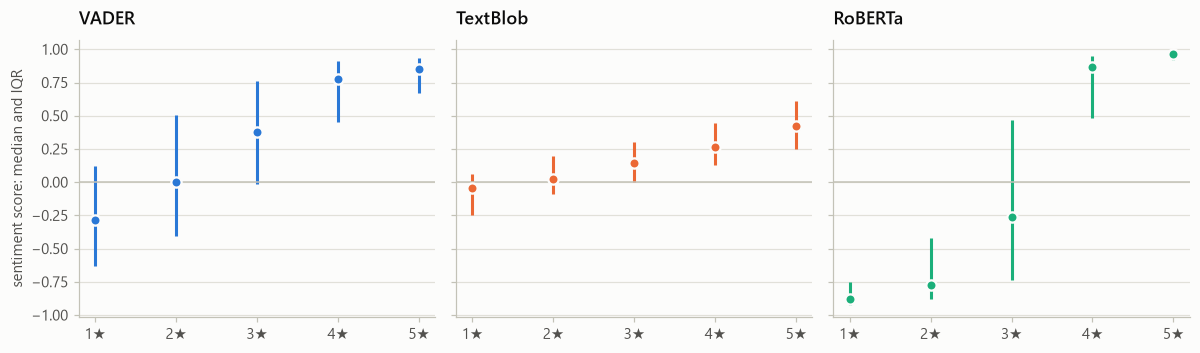

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3), sharey=True)
stars = [1, 2, 3, 4, 5]
for ax, m in zip(axes, MODELS):
    q = df.groupby("rating")[m].quantile([0.25, 0.5, 0.75]).unstack()
    ax.vlines(q.index, q[0.25], q[0.75], color=MODEL_COLORS[m], linewidth=2)
    ax.scatter(q.index, q[0.5], color=MODEL_COLORS[m], s=45, zorder=3, edgecolor=SURFACE, linewidth=1.5)
    ax.axhline(0, color=AXIS, linewidth=1)
    ax.set_xticks(stars, [f"{s}★" for s in stars])
    ax.set_title(MODEL_LABELS[m])
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("sentiment score: median and IQR")
fig.tight_layout()
savefig(fig, "02_scores_by_star")

y = polar.rating_pol > 0
validity = pd.DataFrame({
    MODEL_LABELS.get(m, "Ensemble (mean of z-scores / majority vote)"): {
        "AUC, 4–5★ vs 1–2★": roc_auc_score(y, polar[m]),
        "Spearman ρ with stars": spearman(df[m], df.rating),
        "3-class agreement with rating polarity": (df[f"{m}_pol" if m in MODELS else "text_pol"]
                                                   == df.rating_pol).mean(),
    } for m in MODELS + ["text_score"]}).T
validity.round(3)

## Where each model's labels land, by star rating

The cells are row-normalised. The top-left cell (4–5★ reviews with negative text) and the bottom-right
cell (1–2★ reviews with positive text) are the **reversals** the project counts. The lexicons call a
third of 1–2★ reviews positive, while RoBERTa calls 5% positive. Few 3★ reviews read as neutral to any
model: the lexicons lean positive and RoBERTa leans negative. A 3★ rating has no opposite polarity, so
3★ reviews are excluded from the inconsistency definition.

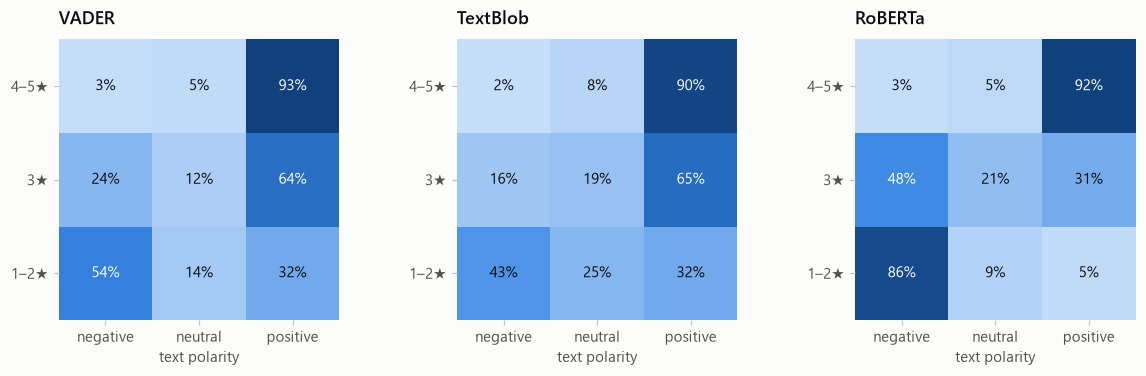

In [3]:
cmap = LinearSegmentedColormap.from_list("blue", BLUE_RAMP)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, m in zip(axes, MODELS):
    ct = (pd.crosstab(df.rating_pol, df[f"{m}_pol"], normalize="index")
            .reindex(index=[1, 0, -1], columns=[-1, 0, 1]).fillna(0))
    ax.imshow(ct.to_numpy(), cmap=cmap, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            v = ct.to_numpy()[i, j]
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9.5,
                    color="white" if v > 0.45 else INK)
    ax.set_xticks(range(3), ["negative", "neutral", "positive"])
    ax.set_yticks(range(3), ["4–5★", "3★", "1–2★"])
    ax.set_xlabel("text polarity", color=INK_2)
    ax.set_title(MODEL_LABELS[m])
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
fig.tight_layout()
savefig(fig, "02_confusion_by_model")

## How much do the three models agree?

In [4]:
pols = df[[f"{m}_pol" for m in MODELS]].to_numpy()
n_distinct = np.array([len(set(r)) for r in pols])
agreement = pd.Series({
    "Fleiss' κ (3 models, 3 classes)": fleiss_kappa(pols),
    **{f"Cohen's κ {MODEL_LABELS[a]}–{MODEL_LABELS[b]}": cohen_kappa_score(df[f"{a}_pol"], df[f"{b}_pol"])
       for a, b in combinations(MODELS, 2)},
    "all three models agree": (n_distinct == 1).mean(),
    "exactly two agree": (n_distinct == 2).mean(),
    "all three differ (ambiguous)": (n_distinct == 3).mean(),
})
display(agreement.round(3).to_frame("value"))

# Of the reviews one model flags as reversed, the share each other model also flags.
overlap = pd.DataFrame({MODEL_LABELS[a]: {MODEL_LABELS[b]: polar.loc[polar[f"rev_{a}"], f"rev_{b}"].mean()
                                           for b in MODELS} for a in MODELS})
overlap.index.name = "also flagged by ↓ / flagged by →"
overlap.round(2)

,value
"Fleiss' κ (3 models, 3 classes)",0.533
Cohen's κ VADER–TextBlob,0.551
Cohen's κ VADER–RoBERTa,0.567
Cohen's κ TextBlob–RoBERTa,0.492
all three models agree,0.729
exactly two agree,0.237
all three differ (ambiguous),0.034


,VADER,TextBlob,RoBERTa
also flagged by ↓ / flagged by →,,,
VADER,1.00,0.55,0.50
TextBlob,0.53,1.00,0.43
RoBERTa,0.17,0.15,1.00


## Which models flag a reversal, and does a majority vote work?

The pattern codes list which models flag a review: **V** = VADER, **T** = TextBlob, **R** = RoBERTa.
For example, `VT-` means both lexicons flag the review and RoBERTa does not.

The obvious rule is a 2-of-3 majority vote. It is dominated by the `VT-` pattern, which is almost
entirely 1–2★ reviews. The two lexicon models are **not independent votes**. Both score individual
words, so both misread negative reviews built from positive words, such as "Don't waste your money",
"Wouldn't buy again" and "Don't listen to the 'good' reviews".

In [5]:
patterns = (polar.groupby("flag_pattern")
                 .agg(reviews=("rating", "size"), share_4_5_star=("rating", lambda r: (r >= 4).mean())))
patterns["share_of_polar_reviews"] = patterns.reviews / len(polar)
patterns.sort_values("reviews", ascending=False).round(3)

,reviews,share_4_5_star,share_of_polar_reviews
flag_pattern,,,
---,546043,0.855,0.855
V--,24743,0.309,0.039
VT-,24600,0.066,0.039
-T-,23670,0.263,0.037
--R,8047,0.947,0.013
VTR,6748,0.255,0.011
V-R,3087,0.798,0.005
-TR,1594,0.666,0.002


## Validating the detector: a manual audit

Each audited review received one of four labels, judged by whether the text's **overall
evaluation** runs opposite to the stars:

* **I** (inconsistent): the verdict clearly runs opposite to the stars, e.g. 5★ for "It broke right
  away", or 1★ for "Great. I love it"
* **M** (mixed): real praise and real complaints, where the stars are a defensible summary, e.g.
  2★ for "Great color! But it peeled after one day"
* **C** (consistent): a model error. The text matches the stars
* **U** (unclear): not evaluative

The audit had three rounds. **Round 1** was exploratory and the labeller could see the model scores.
**Rounds 2 and 3** were blinded: only the stars and the text were visible, and the strata were
shuffled together. The labels are in `reports/audit_labels.csv`.

*The labeller was the AI assistant that built this pipeline, not an independent human annotator.
Treat these figures as a first estimate, and extend or check them with human labels using
`reports/validation_sample.csv`.*

In [6]:
from common import wilson
from config import ROOT

audit = (pd.read_csv(ROOT / "reports" / "audit_labels.csv")
           .merge(df[["review_id", "flag_pattern", "p_opposite"]], on="review_id"))
summary = audit.groupby("group").label.value_counts().unstack(fill_value=0).reindex(columns=list("ICMU"),
                                                                                   fill_value=0)
summary["audited"] = summary.sum(axis=1)
summary["precision"], summary["lo"], summary["hi"] = wilson(summary.I, summary.audited)
summary["I or M"] = (summary.I + summary.M) / summary.audited
summary.round(2)

label,I,C,M,U,audited,precision,lo,hi,I or M
group,,,,,,,,,
"anchored, 1-2 stars",10,41,18,1,70,0.14,0.08,0.24,0.4
"anchored, 4-5 stars",29,20,20,1,70,0.41,0.31,0.53,0.7
"lexicon-only (VADER+TextBlob, not RoBERTa)",0,27,3,0,30,0.00,0.00,0.11,0.1
"one-lexicon-only, 1-2 stars",0,24,0,0,24,0.00,0.00,0.14,0.0
"one-lexicon-only, 4-5 stars",0,5,0,1,6,0.00,0.00,0.39,0.0
"roberta-only, 1-2 stars",0,2,0,0,2,0.00,0.00,0.66,0.0
"roberta-only, 4-5 stars",7,14,7,0,28,0.25,0.13,0.43,0.5
"unflagged, 1-2 stars",0,1,0,0,1,0.00,0.00,0.79,0.0
"unflagged, 4-5 stars",0,19,0,0,19,0.00,0.00,0.17,0.0


The audit gives four conclusions:

* **Lexicon-only flags are noise.** None of the 60 audited reviews flagged by one or both lexicons,
  without RoBERTa, was truly inconsistent.
* **RoBERTa carries the signal.** When RoBERTa flags a 4–5★ review, a real reversal is common. For
  1–2★ reviews, even RoBERTa-anchored flags are mostly *mixed* reviews that open with praise before
  the complaint.
* The working definition is therefore **RoBERTa-anchored**: `inconsistent` = RoBERTa reverses **and**
  at least one lexicon agrees. The naive majority is kept as `inconsistent_majority` for comparison.
* Precision rises with RoBERTa's confidence, as the next table shows. A high-precision variant,
  `inconsistent_confident` (P(opposite class) ≥ 0.8), is used as a robustness check.

In [7]:
anch = audit[audit.group.str.startswith("anchored")]
pd.DataFrame({g: {f"P(opposite) ≥ {t}": f"{(s.p_opposite >= t).sum()} kept, "
                                         f"precision {s.loc[s.p_opposite >= t, 'label'].eq('I').mean():.2f}"
                  for t in [0.34, 0.5, 0.7, 0.8, 0.9]} for g, s in anch.groupby("group")})

,"anchored, 1-2 stars","anchored, 4-5 stars"
P(opposite) ≥ 0.34,"70 kept, precision 0.14","70 kept, precision 0.41"
P(opposite) ≥ 0.5,"58 kept, precision 0.17","63 kept, precision 0.44"
P(opposite) ≥ 0.7,"36 kept, precision 0.25","42 kept, precision 0.52"
P(opposite) ≥ 0.8,"29 kept, precision 0.28","22 kept, precision 0.64"
P(opposite) ≥ 0.9,"17 kept, precision 0.35","6 kept, precision 0.83"


## How sensitive is the reversal rate to the thresholds?

A wider neutral band makes the lexicon models more conservative. For RoBERTa, we can additionally
require a minimum probability for the opposite class. The vertical lines mark the settings used.

The lexicon rates depend heavily on this arbitrary cut-off. TextBlob's rate falls from 11% to under
1% across the range. This is one more reason not to let the lexicons decide on their own. RoBERTa's
rate declines steadily as the required confidence rises, and the audit below uses that to trade
recall for precision.

,band,VADER,TextBlob
0,0.0,0.0957,0.1099
5,0.1,0.0888,0.0678
10,0.2,0.0798,0.0384
15,0.3,0.0676,0.0218
20,0.4,0.0557,0.0118
25,0.5,0.0443,0.0054


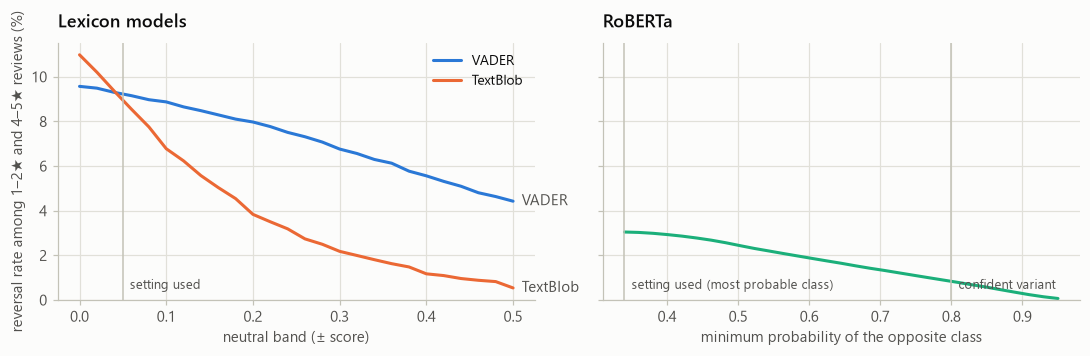

In [8]:
bands = np.linspace(0, 0.5, 26)
thresholds = np.linspace(0.34, 0.95, 31)
lex = {m: [((np.sign(polar[m]) == -polar.rating_pol) & (polar[m].abs() > b)).mean() for b in bands]
       for m in ["vader", "textblob"]}
p_opposite = np.where(polar.rating_pol > 0, polar.rb_neg, polar.rb_pos)
rb = [(polar.rev_roberta & (p_opposite >= t)).mean() for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.3), sharey=True)
for m, rates in lex.items():
    axes[0].plot(bands, 100 * np.array(rates), color=MODEL_COLORS[m], label=MODEL_LABELS[m])
    axes[0].text(bands[-1] + 0.01, 100 * rates[-1], MODEL_LABELS[m], color=INK_2, va="center")
axes[0].axvline(0.05, color=AXIS, linewidth=1)
axes[0].text(0.058, 0.5, "setting used", color=INK_2, fontsize=8.5)
axes[0].set_xlabel("neutral band (± score)")
axes[0].set_ylabel("reversal rate among 1–2★ and 4–5★ reviews (%)")
axes[0].set_title("Lexicon models")
axes[0].legend(loc="upper right")
axes[1].plot(thresholds, 100 * np.array(rb), color=MODEL_COLORS["roberta"])
axes[1].axvline(0.34, color=AXIS, linewidth=1)
axes[1].text(0.35, 0.5, "setting used (most probable class)", color=INK_2, fontsize=8.5)
axes[1].axvline(0.8, color=AXIS, linewidth=1)
axes[1].text(0.81, 0.5, "confident variant", color=INK_2, fontsize=8.5)
axes[1].set_xlabel("minimum probability of the opposite class")
axes[1].set_title("RoBERTa")
axes[0].set_ylim(bottom=0)
fig.tight_layout()
savefig(fig, "02_threshold_sensitivity")
pd.DataFrame({"band": bands, **{MODEL_LABELS[m]: r for m, r in lex.items()}}).iloc[::5].round(4)

## Measurement quality depends on review length

All three models work best on reviews of 6–30 words. They are slightly worse on very short reviews
and clearly worse on long ones: at 121+ words, VADER's AUC is 0.85 and RoBERTa's is 0.95. Long
reviews mix praise and complaints, and RoBERTa sees only the first 128 and last 126 tokens of reviews
longer than 256 tokens. This measurement error matters when length is interpreted as a *predictor*
of inconsistency in notebook 4.

In [9]:
length_bins = pd.cut(polar.word_count, [-1, 5, 15, 30, 60, 120, np.inf],
                     labels=["≤5", "6–15", "16–30", "31–60", "61–120", "121+"])
auc_by_length = pd.DataFrame({
    MODEL_LABELS.get(m, "Ensemble"): polar.groupby(length_bins, observed=True).apply(
        lambda g: roc_auc_score(g.rating_pol > 0, g[m]) if g.rating_pol.nunique() == 2 else np.nan)
    for m in MODELS + ["text_score"]})
auc_by_length["reviews"] = length_bins.value_counts(sort=False)
auc_by_length.round(3)

,VADER,TextBlob,RoBERTa,Ensemble,reviews
word_count,,,,,
≤5,0.939,0.909,0.979,0.970,72275
6–15,0.945,0.909,0.988,0.978,164581
16–30,0.940,0.898,0.988,0.976,154863
31–60,0.920,0.877,0.986,0.970,147736
61–120,0.896,0.860,0.980,0.963,72690
121+,0.854,0.833,0.951,0.944,26387


## Titles and bodies sometimes disagree

In some reviews the title and body point in opposite directions, for example the title "Love the
smell" over a body complaining about a rash. That is one mechanism behind rating–text inconsistency,
because the reader and the models see both.

In [10]:
both = df[(df.vader_title.notna()) & (df.vader_body.notna())]
tp = np.select([both.vader_title > 0.05, both.vader_title < -0.05], [1, -1], 0)
bp = np.select([both.vader_body > 0.05, both.vader_body < -0.05], [1, -1], 0)
print(f"reviews with a user title and a body: {len(both):,}")
print(f"title and body have opposite VADER polarity: {(tp * bp == -1).mean():.1%}")

reviews with a user title and a body: 619,059
title and body have opposite VADER polarity: 7.5%
